# Equity Factor Analysis: Value vs Growth in the STOXX 600 Index as a proxy for the European Market

This project constructs value and growth portfolios using price-to-book ratios for the STOXX 600 and examines their performance relative to the market index using month-end data between from January 2010 to December 2025. Data is sourced from Bloomberg via BQL. Portfolios are rebalanced monthly and cap-weighted within each factor bucket. P/B is lagged one month to avoid look-ahead bias.

## 0. Libraries

In [76]:
#importing libraries
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'svg'
import seaborn as sns

## 1. Import & Clean Data

Data for month-end adjusted prices, market capitalisations, and price-to-book ratios for STOXX 600 members were downloaded from Bloomberg via BQL and saved as CSVs. NaNs are present where a ticker was not an index constituent at that given date. The datasets are cleaned, aligned by date and ticker, and converted to the correct formats.

In [77]:
#load CSVs
prices_df = pd.read_csv('prices_monthly.csv', low_memory = False)
mkt_cap_df = pd.read_csv('market_cap_monthly.csv', low_memory = False)
pb_df = pd.read_csv('price_to_book_monthly.csv', low_memory = False)

In [78]:
#clean up dataframes

def clean_bloomberg_df(df):
    #remove empty rows & delete index 0
    df = df.dropna(how = 'all')
    df = df.drop(index=0)
    #rename date column & set as index
    df = df.rename(columns={df.columns[0]: 'Date'})
    df = df.set_index('Date')
    #keep remaining NaNs - ticker not in index at that date. Drop 'Equity' from ticker names
    df.columns = df.columns.str.replace(' Equity', '', regex = False)
    #check dataframes are in the right formats and shapes. parse dates to change from strings to datetime index
    df.index = pd.to_datetime(df.index, dayfirst = True)
    #convert number strings to numbers
    df = df.apply(pd.to_numeric, errors = 'coerce')
    return df

prices_df = clean_bloomberg_df(prices_df)
mkt_cap_df = clean_bloomberg_df(mkt_cap_df)
pb_df = clean_bloomberg_df(pb_df)
    
#align dates and tickers
common_dates = prices_df.index.intersection(mkt_cap_df.index).intersection(pb_df.index)
common_tickers = prices_df.columns.intersection(mkt_cap_df.columns).intersection(pb_df.columns)

prices_df = prices_df.loc[common_dates, common_tickers]
mkt_cap_df = mkt_cap_df.loc[common_dates, common_tickers]
pb_df = pb_df.loc[common_dates, common_tickers]

print(f"Dataset: {len(common_dates)} months | {len(common_tickers)} tickers")
print(f"Date range: {common_dates.min().date()} to {common_dates.max().date()}")

Dataset: 192 months | 600 tickers
Date range: 2010-01-31 to 2025-12-31


## 2. Returns & Index Construction

Monthly returns are computed from adjusted (e.g. stock splits) share price data using simple percentage changes. Index returns are constructed using index weights derived from market cap data as a share of total index market capitalisation. P/B data is lagged by one month to avoid look-ahead bias in portfolio construction.

In [79]:
#create new dataframes

#create monthly stock returns dataframe
returns_df = prices_df.pct_change()

#lag P/B by one month to avoid look ahead bias
pb_lag_df = pb_df.shift(1)

#create index weights from market caps
weights_df = mkt_cap_df.div(mkt_cap_df.sum(axis=1), axis=0)

#create index returns
returns_index = (weights_df * returns_df).sum(axis=1)

## 3. Value & Growth Portfolio Construction

Stocks are ranked monthly by P/B ratio. The bottom 30% of index constituents are classified as the Value portfolio, and the top 30% make up the Growth portfolio.

Portfolios are cap-weighted within each bucket to mimic the original index and rebalanced monthly. The value premium can then be calculated as the monthly return spread between value and growth.

In [80]:
#value or growth classification, bottom 30 percentile value, top 30 growth
pb_pct_df = pb_lag_df.rank(axis = 1, pct = True)
value_stocks_df = pb_pct_df <= 0.3
growth_stocks_df = pb_pct_df >= 0.7

#apply cap weights
weights_value_df = weights_df.where(value_stocks_df, 0)
weights_growth_df = weights_df.where(growth_stocks_df, 0)

#renormalise weights to sum to 1
weights_value_df = weights_value_df.div(weights_value_df.sum(axis=1), axis=0)
weights_growth_df = weights_growth_df.div(weights_growth_df.sum(axis=1), axis=0)

#calculate portfolio returns for value and growth
returns_value = (weights_value_df * returns_df).sum(axis=1)
returns_growth = (weights_growth_df * returns_df).sum(axis=1)

#calculate value premium as monthly return spread between value and growth
value_premium = returns_value - returns_growth

#combine returns into a single dataframe
portfolio_returns_df = pd.DataFrame({
    'Value': returns_value,
    'Growth': returns_growth,
    'Index': returns_index
})

## 4. Portfolio Turnover

Monthly portfolio turnover is calculated as the sum of absolute weights changes between rebalances. This captures both index drift (stocks moving in/out of the factor bucket) and active rebalancing.

This is important to consider as high turnover stratgies imply high transaction costs that can erode net returns. The value portfolio turns over c.16.2% per month vs c.11.6% for growth. As expected, this is much higher than the index turnover of c.4.8% due to the shifting P/B valuations each month.

In [81]:
#calculate turnover function from weights dataframes

def calculate_turnover(weights):
    return weights.diff().abs().sum(axis=1)

turnover_value = calculate_turnover(weights_value_df)
turnover_growth = calculate_turnover(weights_growth_df)
turnover_index = calculate_turnover(weights_df)

print(f"Average monthly turnover — Value: {turnover_value.mean():.1%} | Growth: {turnover_growth.mean():.1%} | Index: {turnover_index.mean():.1%}")

Average monthly turnover — Value: 16.2% | Growth: 11.6% | Index: 4.8%


## 5. Performance Metrics

Standard performance metrics are computed across the full sample period. We assume the Sharpe ratio uses a 0% risk-free rate as a simplifying assumption, whereas we would use the relevant short-term rate (e.g. EURIBOR) in practice.

A performance summary of the three portfolios are included with returns, volatility, Sharpe ratio, max drawdown, and information ratio calculated.

In [82]:
#define performance metric functions from returns

def returns_annualised(r, periods_per_year = 12):
    r = r.dropna()
    return (1 + r).prod() ** (periods_per_year/len(r)) - 1

def volatility_annualised(r, periods_per_year = 12):
    r = r.dropna()
    return r.std() * np.sqrt(periods_per_year)

def sharpe_ratio(r, r_f = 0.0, periods_per_year = 12):
    r = r.dropna()
    ret_annual = returns_annualised(r, periods_per_year)
    vol_annual = volatility_annualised(r, periods_per_year)
    if vol_annual != 0:
        return (ret_annual - r_f) / vol_annual
    else:
        return np.nan

def max_drawdown(r):
    r = r.dropna()
    cumulative = (1 + r).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = cumulative / rolling_max - 1
    return drawdown.min()

def information_ratio(r_portfolio, r_benchmark, periods_per_year = 12):
    active = (r_portfolio - r_benchmark).dropna()
    tracking_error = active.std() * np.sqrt(periods_per_year)
    active_return = active.mean() * periods_per_year
    if tracking_error != 0:
        return active_return / tracking_error
    else:
        return np.nan

#performance metrics in one function

def performance_summary(r, r_benchmark = None, r_f = 0.0, periods_per_year = 12):
    metrics = {
        'Annualised Return': returns_annualised(r, periods_per_year),
        'Annualised Volatility': volatility_annualised(r, periods_per_year),
        'Sharpe Ratio': sharpe_ratio(r, r_f, periods_per_year),
        'Max Drawdown': max_drawdown(r)
    }
    if r_benchmark is not None:
        metrics['Information Ratio'] = information_ratio(r, r_benchmark, periods_per_year)
    return pd.Series(metrics)

#create performance summary using index as benchmark

metrics_value = performance_summary(returns_value, returns_index)
metrics_growth = performance_summary(returns_growth, returns_index)
metrics_index = performance_summary(returns_index)

performance_df = pd.DataFrame({
    'Value': metrics_value,
    'Growth': metrics_growth,
    'Index': metrics_index
}).T

print("\nPerformance Summary")
print(performance_df.round(4).to_string())


Performance Summary
        Annualised Return  Annualised Volatility  Information Ratio  Max Drawdown  Sharpe Ratio
Value              0.1726                 0.1699             0.2040       -0.2845        1.0157
Growth             0.1634                 0.1256             0.0265       -0.2027        1.3014
Index              0.1618                 0.1255                NaN       -0.1922        1.2889


## 6. Alpha, Beta & Statistical Significance

Jensen's alpha (annualised) and market beta are calculated from OLS regression of portfolio excess returns on index excess returns. We then implement a t-test on the monthly value premium to assess whether the return spread between value and growth is statistically distinguishable from zero.

We find Value's alpha to be -1.97% (p=0.303) and Growth's alpha to be +1.75% (p=0.238). Overall we can conclude return is not explained by market exposure as Value's beta (market sensitivity) is higher at 1.225, whereas Growth is 0.900. Therefore, the higher Value returns seems to be explained by more market risk rather than genuine factor alpha. The value premium t-test confirms this, as with t=0.440 and p=0.660 leads to the value premium being statistically insignificant to zero at the 5% significance level given the sample over this period.

In [83]:
#compute alpha and beta function

def calculate_alpha_beta(r_portfolio, r_market, r_f = 0.0, periods_per_year = 12):
    excess_portfolio = (r_portfolio - r_f).dropna()
    excess_market = (r_market - r_f).reindex(excess_portfolio.index).dropna()
    aligned = pd.concat([excess_portfolio, excess_market], axis=1).dropna()
    X = sm.add_constant(aligned.iloc[:, 1])
    model = sm.OLS(aligned.iloc[:, 0], X).fit()
    alpha_monthly = model.params['const']
    beta = model.params.iloc[1]
    alpha_annualised = (1 + alpha_monthly) ** periods_per_year - 1
    output = {
        'Alpha (annualised)': alpha_annualised,
    'Beta': beta,
    'R-squared': model.rsquared,
    'Alpha p-value': model.pvalues['const']
    }
    return output

#find alpha and beta for portfolios

alpha_beta_value = calculate_alpha_beta(returns_value, returns_index)
alpha_beta_growth = calculate_alpha_beta(returns_growth, returns_index)

print("\nAlpha & Beta vs STOXX 600 Index")
ab_df = pd.DataFrame({'Value': alpha_beta_value, 'Growth': alpha_beta_growth})
print(ab_df.round(4).to_string())


Alpha & Beta vs STOXX 600 Index
                     Value  Growth
Alpha (annualised) -0.0197  0.0175
Beta                1.2252  0.9000
R-squared           0.8191  0.8090
Alpha p-value       0.3033  0.2377


In [84]:
#t-test on value premium

premium_clean = value_premium.dropna()
t_stat, p_value = stats.ttest_1samp(premium_clean, 0)
print(f"\nValue Premium T-Test")
print(f"Mean monthly premium: {premium_clean.mean():4f} ({premium_clean.mean()*12:.2%} annualised)")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"Statistically significant at 5%: {'Yes' if p_value < 0.05 else 'No'}")


Value Premium T-Test
Mean monthly premium: 0.001194 (1.43% annualised)
T-statistic: 0.440
P-value: 0.660
Statistically significant at 5%: No


## 7. Portfolio Visualisations

## 7a. Cumulative Returns
Cumulative returns of value, growth, and the market index are plotted using Plotly Express. Value has performed best over the time period (c.1,177%), whilst Growth (c.1,027%) and the Index (c.1,001%) lagged behind. The paths taken by the portfolios have been different through the time period. Growth had led consistently between c.2014 to the end of 2021, outperforming in the low-rate environment. Value then rallied from 2022, overtaking the Growth and Index portfolios, spurred on by the strong performance from low P/B sectors, such as banks and defence companies, as interest rates rose.

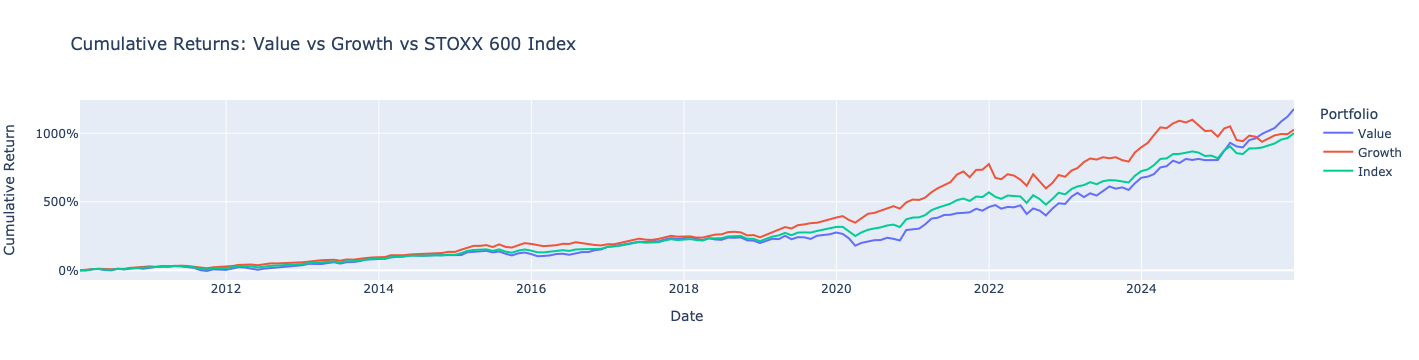

In [85]:
#plotting cumulative returns

cum_returns_df = (1 + portfolio_returns_df).cumprod() - 1
cum_returns_long = cum_returns_df.reset_index().melt(id_vars = 'Date', var_name = 'Portfolio', value_name = 'Cumulative Return')

fig = px.line(cum_returns_long, x='Date', y='Cumulative Return', color='Portfolio', title='Cumulative Returns: Value vs Growth vs STOXX 600 Index')
fig.update_layout(yaxis_tickformat='.0%')
fig.show()

## 7b. Drawdown (Underwater Curve)

The underwater curve shows how far each portfolio sits below its prior all-time high at each point in time, giving more information that a single max drawdown figure.

Value's worst drawdown was -28.5% (September 2011, Eurozone debt crisis), materially worse than Growth (-20.3%, September 2022) and the Index (-19.2%, September 2011). This is consistent with our observation that Value has higher beta, and so will fall more in risk-off environments.

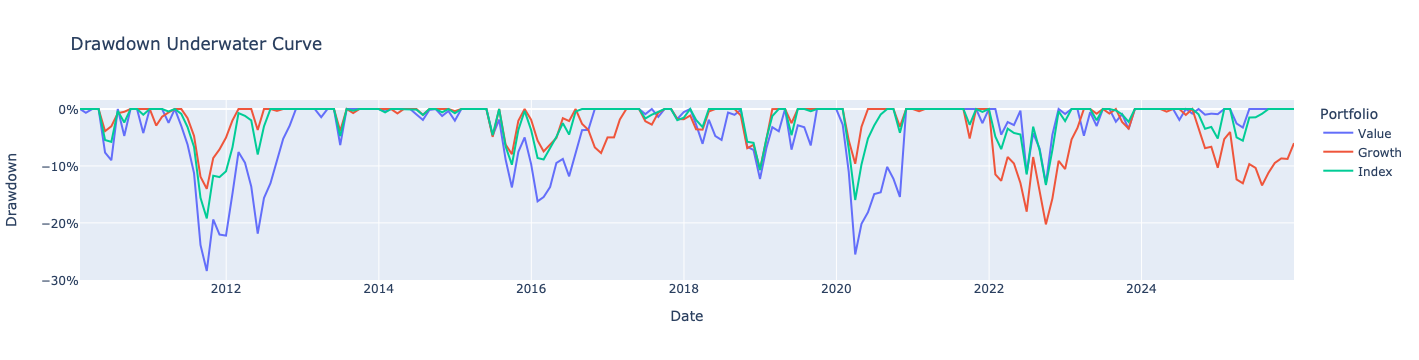

In [87]:
#underwater drawdown chart

def drawdown_series(r):
    cumulative = (1+r.dropna()).cumprod()
    return cumulative / cumulative.cummax() -1

dd_df = pd.DataFrame({
    'Value': drawdown_series(returns_value),
    'Growth': drawdown_series(returns_growth),
    'Index': drawdown_series(returns_index)
})

dd_long = dd_df.reset_index().melt(id_vars = 'Date', var_name = 'Portfolio', value_name = 'Drawdown')

fig = px.line(dd_long, x = 'Date', y = 'Drawdown', color = 'Portfolio', title = 'Drawdown Underwater Curve')
fig.update_layout(yaxis_tickformat='.0%')
fig.show()

## 7c. Performance Metric Charts

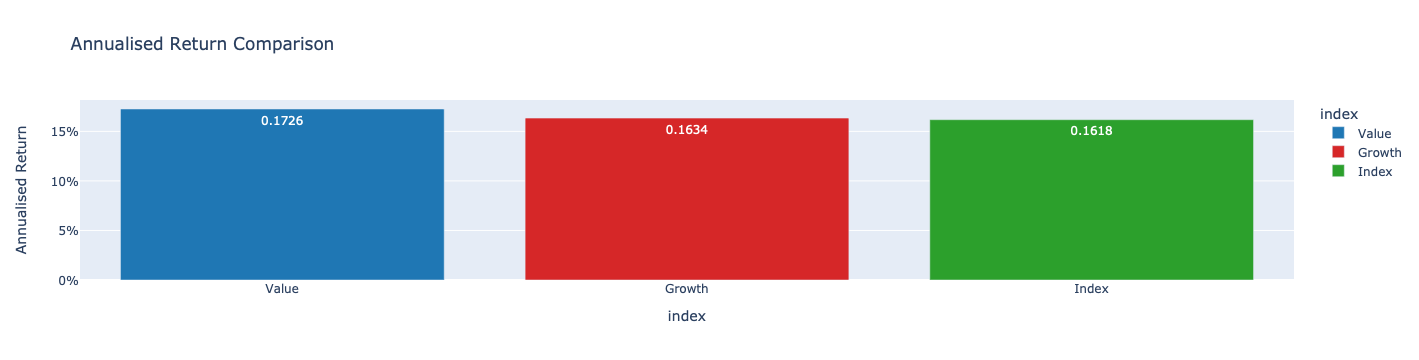

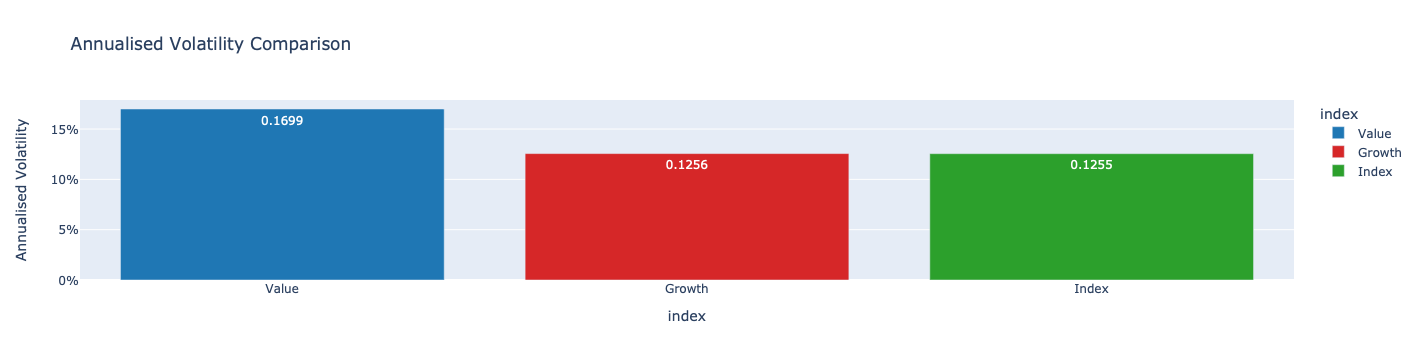

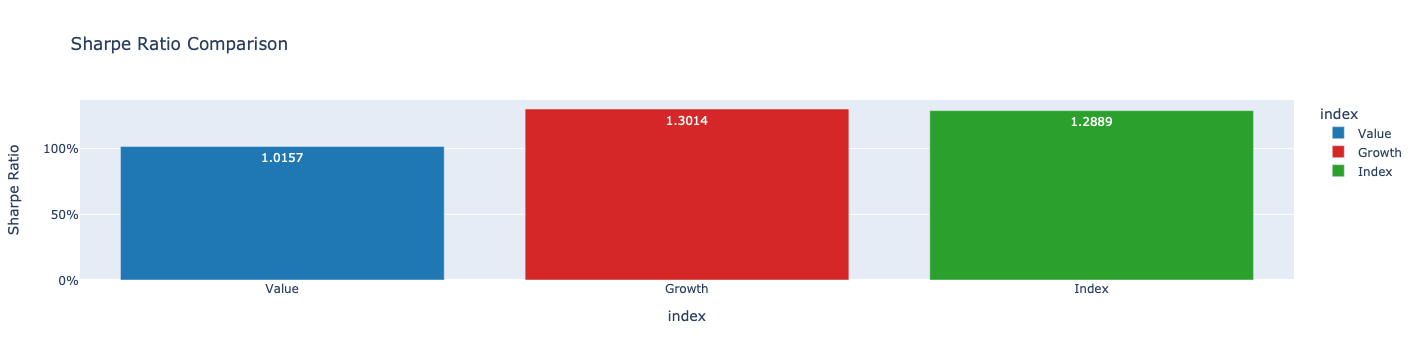

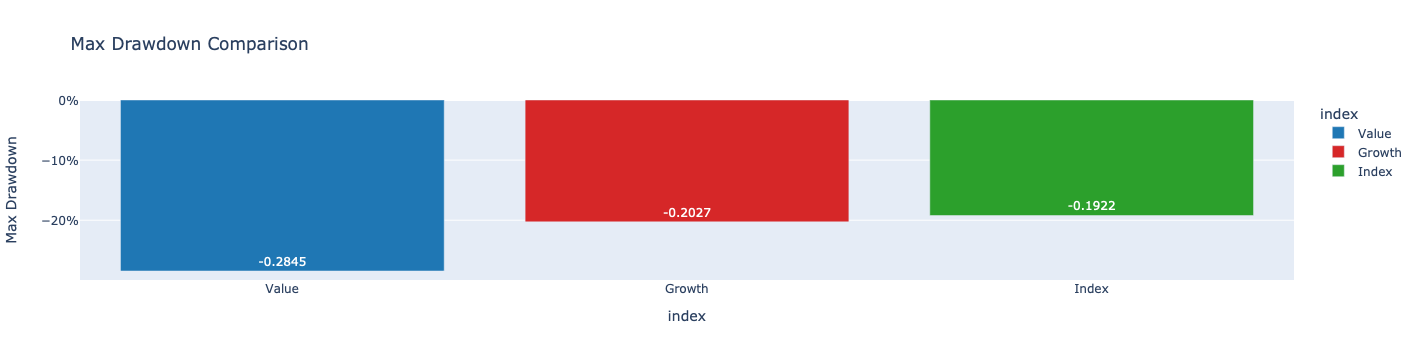

In [86]:
#plotting performance metrics
metrics_to_plot = ['Annualised Return', 'Annualised Volatility', 'Sharpe Ratio', 'Max Drawdown']

color_map = {'Value': '#1f77b4', 'Growth': '#d62728', 'Index': '#2ca02c'}

for metric in metrics_to_plot:
    fig = px.bar(performance_df, y = metric, x = performance_df.index,
                 text = performance_df[metric].round(4),
                 title = f'{metric} Comparison',
                 labels = {'x': 'Portfolio', metric: metric},
                 color = performance_df.index,
                 color_discrete_map = color_map
                )
    fig.update_traces(textposition = 'inside', textfont_color = 'white')
    fig.update_layout(yaxis = dict(title=metric), yaxis_tickformat='.0%')
    fig.show()

## 7d. Rolling 12-Month Metrics

Rolling metrics are calculated to show how performance characteristics have evolved over time and across market regimes, rather than simplifying into a single full-period average.

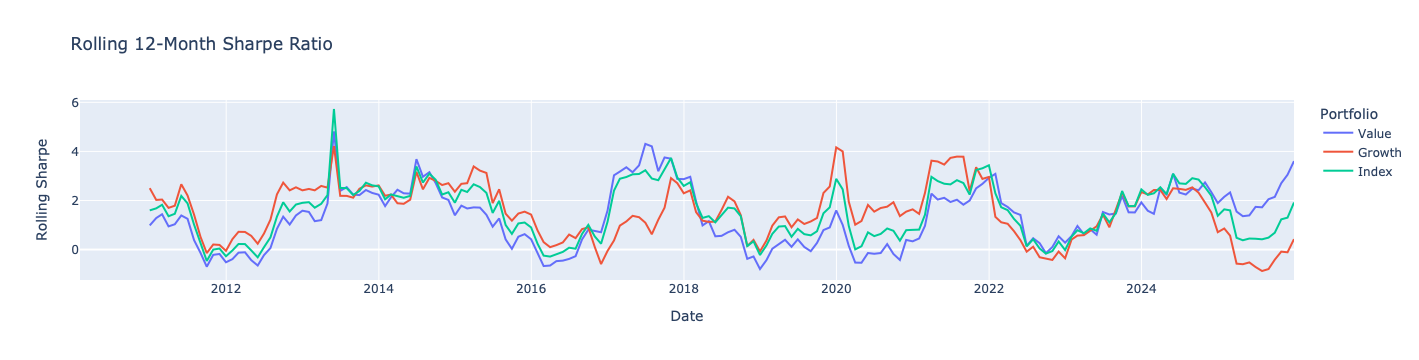

In [88]:
#calculating and plotting rolling 12 month Sharpe ratios

window = 12

#rolling Sharpe function
def rolling_sharpe(r, window, r_f = 0.0, periods_per_year = 12):
    rolling_mean = r.rolling(window).mean() * periods_per_year
    rolling_std = r.rolling(window).std() * np.sqrt(periods_per_year)
    rolling_sharpe = (rolling_mean - r_f) / rolling_std
    return rolling_sharpe

#DataFrame for plotting
rolling_sharpe_df = pd.DataFrame({
    'Value': rolling_sharpe(returns_value, window),
    'Growth': rolling_sharpe(returns_growth, window),
    'Index': rolling_sharpe(returns_index, window)
})

rolling_sharpe_long = rolling_sharpe_df.reset_index().melt(id_vars = 'Date', var_name = 'Portfolio', value_name = 'Rolling Sharpe')

#plot
fig = px.line(rolling_sharpe_long, x='Date', y='Rolling Sharpe', color = 'Portfolio', title = 'Rolling 12-Month Sharpe Ratio')
fig.show()

In [89]:
#rolling volatility DataFrame
rolling_vol_df = pd.DataFrame({
    'Value': returns_value.rolling(window).std() * np.sqrt(12),
    'Growth': returns_growth.rolling(window).std() * np.sqrt(12),
    'Index': returns_index.rolling(window).std() * np.sqrt(12)
})

rolling_vol_long = rolling_vol_df.reset_index().melt(id_vars='Date', var_name='Portfolio', value_name='Rolling Volatility')

#plot
fig_volatility = px.line(rolling_vol_long, x='Date', y='Rolling Volatility', color='Portfolio', title='Rolling 12-Month Annualised Volatility')
fig_volatility.update_layout(yaxis_tickformat='.0%')
fig_volatility.show()

In [90]:
#rolling annualised returns DataFrame
rolling_returns_df = pd.DataFrame({
    'Value': (1 + returns_value).rolling(window).apply(np.prod, raw=True) - 1,
    'Growth': (1 + returns_growth).rolling(window).apply(np.prod, raw=True) - 1,
    'Index': (1 + returns_index).rolling(window).apply(np.prod, raw=True) - 1
})

rolling_returns_long = (rolling_returns_df.reset_index().melt(id_vars='Date', var_name='Portfolio', value_name='Rolling Return'))

#plot
fig = px.line(rolling_returns_long, x='Date', y='Rolling Return', color='Portfolio', title='Rolling 12-Month Returns')
fig.update_layout(yaxis_tickformat='.0%')
fig.show()

## 7e. Correlations

Value and Growth portfolios are highly correlated with the index (0.91 and 0.9 respectively), which we can expect as they are subsets of the total index. This confirms they are both primarily driven by broad market beta. The lower Value vs Growth correlation of 0.65 reflects the genuine divergence in sectoral composition and economic sensitivity between the two factor buckets.

The rolling correlation charts reveals that the Value vs Growth correlation is highly unstable as it ranges from 0.11 to 0.93, showing us the relationship is strongly regime-dependent. For example, 2017 shows this, where the correlation dropped to as low as 0.11. This coincided with a period of strong, narrow growth-led market leadership (tech and consumer staples re-rating) while value stocks (banks, industrials) stagnated. the two portfolios were essentially moving independently of each other, meaning factor selection has an unusually high impact on relative returns. Over time, the correlation dropped from an average of 0.709 (2010-2014) to 0.608 (2022-2025), likely reflecting increasing market polarisation between value and growth.

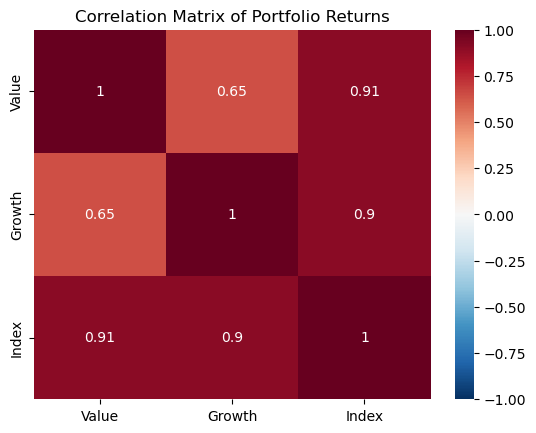

In [91]:
#correlations

#plot portfolio returns with seaborn
sns.heatmap(portfolio_returns_df.corr(), annot = True, cmap = 'RdBu_r', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Portfolio Returns')
plt.show()

In [92]:
#rolling correlations to see how they've changed over time

window = 12

#DataFrame of rolling correlations between the three indexes
rolling_corr_df = pd.DataFrame({
    'Value vs Growth': returns_value.rolling(window).corr(returns_growth),
    'Value vs Index': returns_value.rolling(window).corr(returns_index),
    'Growth vs Index': returns_growth.rolling(window).corr(returns_index)
})

rolling_corr_long = rolling_corr_df.reset_index().melt(id_vars='Date', var_name='Pair', value_name='Rolling Correlation')

#plot
fig = px.line(rolling_corr_long, x='Date', y='Rolling Correlation', color='Pair',
              title='Rolling 12-Month Correlations Between Portfolios')
fig.show()

## 8. Conclusion

In the STOXX 600 over the January 2010 to December 2025 sample period, the value portfolio (bottom 30% P/B stocks) generated a cumulative return of +1,177%, outperforming both the growth portfolio (top 30% P/B stocks, +1,027%) and the cap-weighted index (+1,001%). However, further investigation explores the reasons for this, outlined below.

Key findings:
1. Higher returns was a result of higher risk. The value portfolio's annualised volatility was 17.0% vs 12.6% for growth and 12.6% for the index. Looking at the Sharpe ratio for risk-adjusted returns, value (1.016) underperformed both growth (1.301) and the index (1.289). Value's deeper drawdowns (-28.5% peak-to-trough in the 2011 Eurozone crisis) reflect its higher beta of 1.225, amplifying broad market moves due its concentration in cyclical, financially-leveraged sectors such as banks and energy.

2. The value premium was not statistically significant. The t-test on the monthly return spread between value and growth returned a p-value of 0.660, so the null hypothesis that the premium is zero cannot be rejected. The 1.43% annualised premium is within the bounds of sampling noise over a 15-year period.

3. The outperformance can be explained by regimes. Looking at sub-samples:

   2010-2014: Value +15.5% p.a. vs Growth +18.5% p.a. Value underperformed Growth.

   2015-2021: Value +15.4% p.a. vs Growth +20.7% p.a. Value significantly underperformed Growth.

   2022-2025: Value +22.8% p.a. vs Growth +6.5% p.a. Value significantly outperformed Growth.

   Value's higher cumulative return was largely due to the 2022 onwards regime shift where rate normalisation by the ECB repriced long-duration growth stocks sharply lower, while low P/B financials, energy, and defence names re-rated on improved earnings and higher book values.

4. Alpha vs beta. After adjusting for market beta, value generated an alpha of -1.97% p.a. (p=0.303), statistically indistinguishable from zero. Growth produced +1.75% p.a. alpha (p=0.238), also insignificant. This confirms that neither portfolio generated returns beyond what would be expected given their market risk exposure.

Key limitations of the analysis:
1. Only a single valuation metric, P/B, is used and does not control for sector, country, or other factors such as quality, which could be a further step for analysis. P/B has well-known weaknesses, such as distortion by share buybacks, accounting differences across countries, and is less meaningful for asset-light businesses such as software and pharmaceuticals that tend to be growth stocks. A more complete factor model would incorporate additional signals such as earnings yield or EV multiples.

2. Survivorship bias is also likely present as the members list will not include companies that went bankrupt or were delisted during the sample period, which can bias returns upward, particularly for the value portfolio, which is more likely to hold distressed and financially leveraged stocks.